<a href="https://colab.research.google.com/github/yinyue31/BA820-Team6-Project/blob/main/BA820_Team6_EDA_Alone.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [32]:
from google.colab import data_table
from google.colab import drive
data_table.enable_dataframe_formatter()
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [33]:
import pandas as pd
survivalists = pd.read_csv(
    "/content/drive/MyDrive/BA820 Team 6/survivalists.csv"
)
loadouts = pd.read_csv(
    "/content/drive/MyDrive/BA820 Team 6/loadouts.csv"
)

In [34]:
print(survivalists.shape)
print(loadouts.shape)

print(survivalists.columns)
print(loadouts.columns)


(94, 16)
(940, 6)
Index(['season', 'name', 'age', 'gender', 'city', 'state', 'country', 'result',
       'days_lasted', 'medically_evacuated', 'reason_tapped_out',
       'reason_category', 'team', 'day_linked_up', 'profession', 'url'],
      dtype='object')
Index(['version', 'season', 'name', 'item_number', 'item_detailed', 'item'], dtype='object')


**Distribution of Survival Duration with Extreme Cases Highlighted**

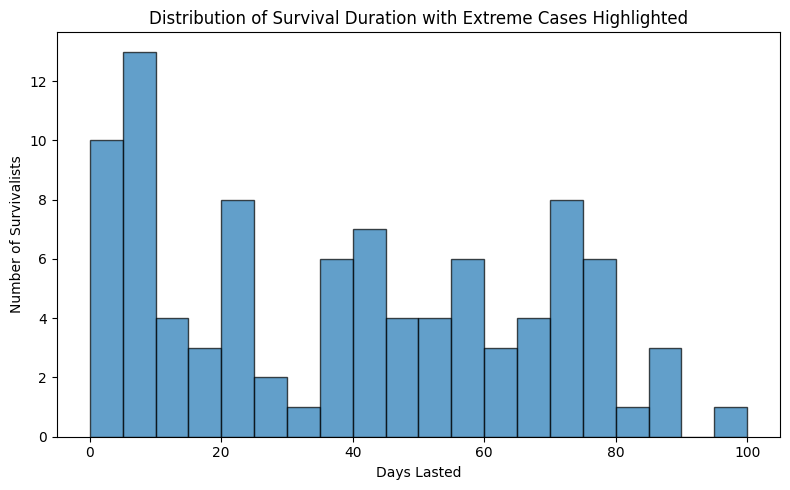

In [35]:
import matplotlib.pyplot as plt

surv_sorted = survivalists.sort_values("days_lasted")

plt.figure(figsize=(8, 5))
plt.hist(
    survivalists["days_lasted"],
    bins=20,
    edgecolor="black",
    alpha=0.7
)

plt.xlabel("Days Lasted")
plt.ylabel("Number of Survivalists")
plt.title("Distribution of Survival Duration with Extreme Cases Highlighted")

plt.tight_layout()
plt.show()


This figure shows a wide distribution of survival durations across participants, with a small number of extreme cases lasting substantially longer or shorter than the majority.
Highlighting these extreme observations helps surface heterogeneity in survival outcomes and raises questions about whether such cases are associated with individual characteristics, environmental conditions, or season-specific factors rather than representing typical experiences.

**Frequency of Tap-Out Reason Categories**

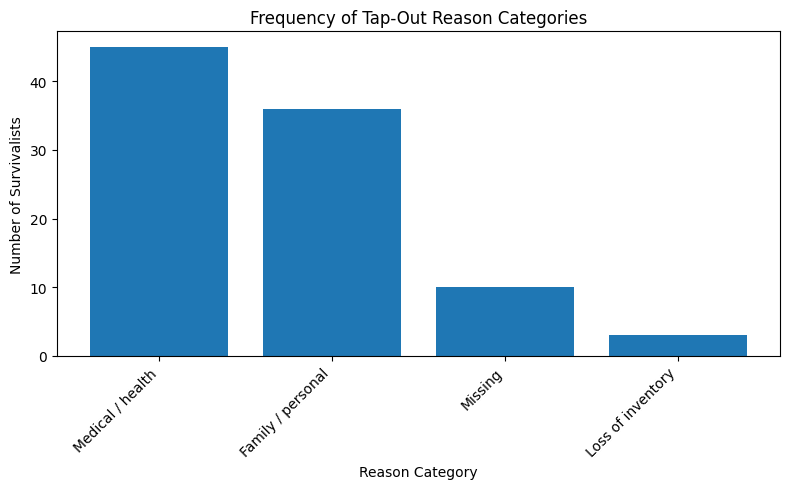

In [36]:
import matplotlib.pyplot as plt
reason_clean = survivalists["reason_category"].fillna("Missing")
reason_counts = reason_clean.value_counts()
plt.figure(figsize=(8, 5))
plt.bar(reason_counts.index, reason_counts.values)
plt.xlabel("Reason Category")
plt.ylabel("Number of Survivalists")
plt.title("Frequency of Tap-Out Reason Categories")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


The distribution of tap-out reasons is highly imbalanced, with medical and family/personal reasons accounting for the majority of cases.
Additionally, the presence of a non-trivial “Missing” category suggests potential reporting limitations, which may affect how reliably tap-out reasons can be compared across participants.

**Exploratory Comparison of Survival Duration by Tap-Out Reason Category**

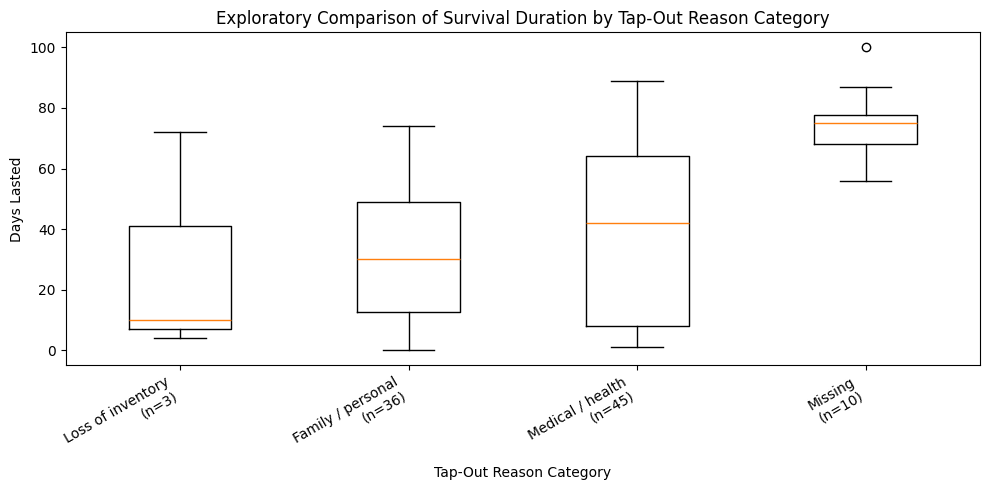

In [37]:
import matplotlib.pyplot as plt

surv_rc = survivalists.copy()
surv_rc["reason_category"] = surv_rc["reason_category"].fillna("Missing")

order = (
    surv_rc.groupby("reason_category")["days_lasted"]
    .median()
    .sort_values()
    .index
    .tolist()
)

counts = surv_rc["reason_category"].value_counts()
labels = [f"{cat}\n(n={counts.get(cat, 0)})" for cat in order]

data = [surv_rc.loc[surv_rc["reason_category"] == cat, "days_lasted"].dropna().values for cat in order]

pos = list(range(1, len(order) + 1))

plt.figure(figsize=(10, 5))
plt.boxplot(data, positions=pos, showfliers=True)

plt.xticks(pos, labels, rotation=30, ha="right")
plt.xlabel("Tap-Out Reason Category")
plt.ylabel("Days Lasted")
plt.title("Exploratory Comparison of Survival Duration by Tap-Out Reason Category")
plt.tight_layout()
plt.show()



This figure provides an exploratory comparison of survival duration across tap-out reason categories.
Although differences in distributions are visible, sample sizes vary substantially—particularly for the loss of inventory and missing categories—limiting interpretability.
As a result, these patterns should be viewed as descriptive rather than evidence of causal relationships.

**Frequency of Loadout Items**

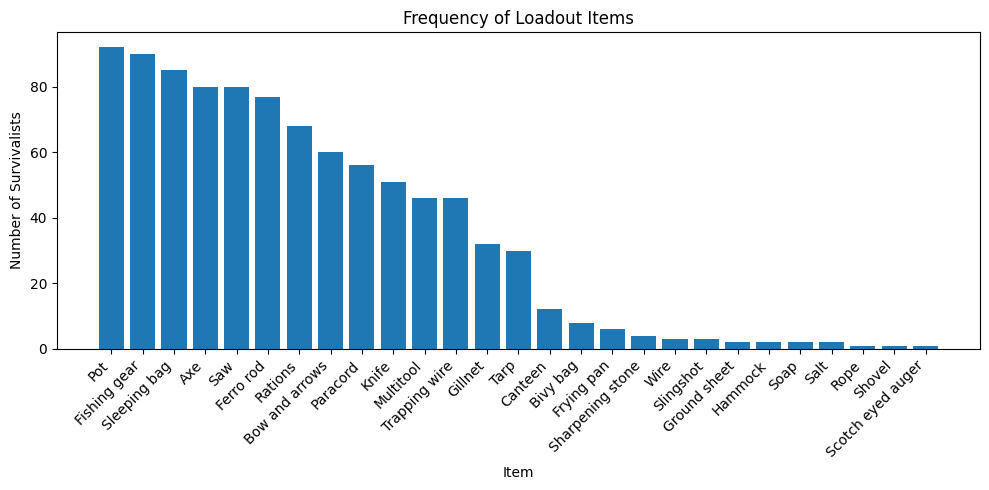

In [38]:
item_counts = loadouts["item"].value_counts()

plt.figure(figsize=(10, 5))
plt.bar(item_counts.index, item_counts.values)
plt.xlabel("Item")
plt.ylabel("Number of Survivalists")
plt.title("Frequency of Loadout Items")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

This figure shows a highly uneven distribution of loadout item selection, with a small set of items chosen by the majority of survivalists and a long tail of infrequently selected items.
It is unclear whether this pattern reflects shared survival strategies, perceived item utility, or constraints imposed by show rules, highlighting an important ambiguity in interpreting item-level frequencies.

**Distribution of Loadout Diversity per Survivalist**

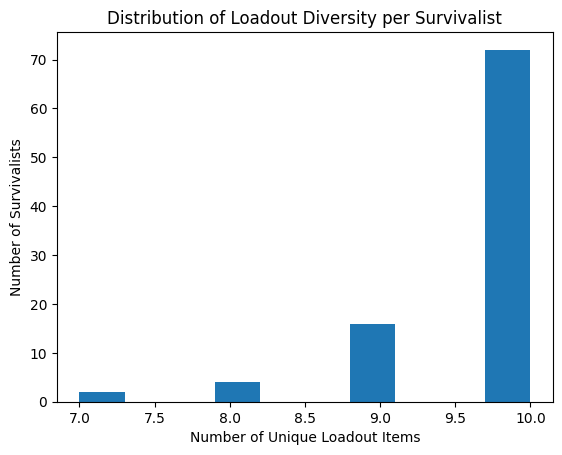

In [39]:
loadout_diversity = (
    loadouts
    .groupby(["season", "name"])["item"]
    .nunique()
    .reset_index(name="n_unique_items")
)

plt.figure()
plt.hist(loadout_diversity["n_unique_items"], bins=10)
plt.xlabel("Number of Unique Loadout Items")
plt.ylabel("Number of Survivalists")
plt.title("Distribution of Loadout Diversity per Survivalist")
plt.show()


The distribution of loadout diversity is highly concentrated, with most survivalists selecting the same number of unique items.
This strong clustering suggests that item count is likely constrained by show rules rather than individual choice, limiting the explanatory power of loadout diversity for understanding survival outcomes.

**Exploratory Relationship Between Survival Duration and Loadout Diversity**

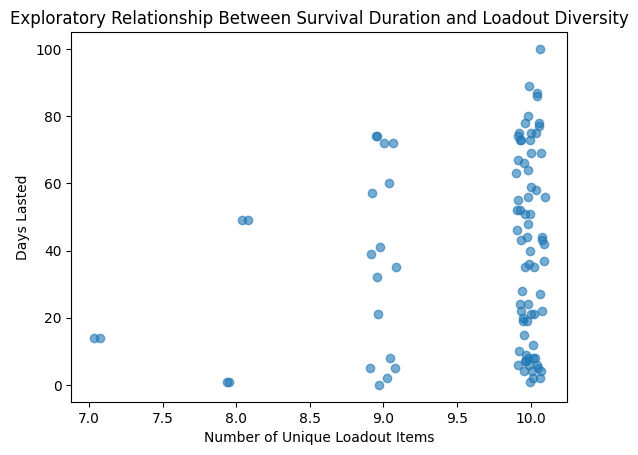

In [40]:
import numpy as np

x_jitter = surv_with_loadout["n_unique_items"] + np.random.uniform(
    -0.1, 0.1, size=len(surv_with_loadout)
)

plt.figure()
plt.scatter(
    x_jitter,
    surv_with_loadout["days_lasted"],
    alpha=0.6
)
plt.xlabel("Number of Unique Loadout Items")
plt.ylabel("Days Lasted")
plt.title("Exploratory Relationship Between Survival Duration and Loadout Diversity")
plt.show()


Due to the limited variation in loadout diversity, observations are heavily clustered, particularly at the maximum item count.
As a result, no clear relationship between loadout diversity and survival duration is evident, suggesting that item count alone provides limited explanatory power.